In [ ]:
from Functions.Graphs import *
from Functions.Utils import *
from scipy.signal import stft
from scipy.signal import hilbert
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import re
fs = 25600

def PlotSTFT(x,fs,nperseg=1024,noverlap=None):
    
    t = np.arange(len(x))*(1/fs)

    x_env = hilbert(x)
    x_env = np.abs(x_env)
    f, t_segment, Zxx = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
    f2, t_segment2, Zxx2 = stft(x_env, fs=fs, nperseg=nperseg,noverlap=noverlap)
    Zxx = np.abs(Zxx)
    Zxx2 = np.abs(Zxx2)
    # 2. Criação da Estrutura com Subplots Lado a Lado
    fig = make_subplots(
        rows=1, cols=2,
        shared_xaxes=True,
        subplot_titles=('Espectrograma STFT (Sinal Bruto)', 'Espectrograma STFT (Envelope)'),
        horizontal_spacing=0.08
    )

    # 3. Adiciona o primeiro Espectrograma (Sinal Original)
    fig.add_trace(
        go.Heatmap(
            z=Zxx,
            x=t_segment,
            y=f,
            colorscale='Viridis',
            zsmooth='fast',  # Equivalente ao shading='gouraud' do Matplotlib
            showscale=False  # Mantém a Colorbar apenas no segundo subplot para não poluir
        ),
        row=1, col=1
    )

    # 4. Adiciona o segundo Espectrograma (Envelope)
    fig.add_trace(
        go.Heatmap(
            z=Zxx2,
            x=t_segment2,
            y=f2,
            colorscale='Viridis',
            zsmooth='fast',
            colorbar=dict(
                title='Magnitude',
                len=1.0  # Ajusta a altura da barra lateral de cores
            )
        ),
        row=1, col=2
    )

    # 5. Configuração Geral do Layout e Rótulos dos Eixos
    fig.update_layout(
        title_text="Análise de Espectrogramas STFT",
        template="plotly_white",
        width=1200,
        height=500,
        margin=dict(t=80, b=50, l=60, r=60)
    )

    # Rótulos dos Eixos X e Y para ambos os subplots
    fig.update_xaxes(title_text="Tempo (Segundos)", row=1, col=1)
    fig.update_xaxes(title_text="Tempo (Segundos)", row=1, col=2)

    fig.update_yaxes(title_text="Frequência (Hz)", row=1, col=1)
    fig.update_yaxes(title_text="Frequência (Hz)", row=1, col=2)

    fig.show()
    

In [ ]:
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\B1_2\160.csv'
df = pd.read_csv(path)
x = df['Horizontal_vibration_signals'].values
x = x - np.mean(x)
PlotSTFT(x,fs,nperseg=256,noverlap=None)


In [ ]:
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\B1_2\Raw\160.csv'
#df = pd.read_csv(path)

def CalculateSTFT(df,fs=25600,horizontal=True,env=False,nperseg=256,noverlap=None):
    if horizontal:
        x = df.iloc[:,0].values
    else:
        x = df.iloc[:,1].values
    if env:
        x = hilbert(x)
        x = np.abs(x)
    else:
        None
    f, t, Z = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
    Z = np.abs(Z)
    col_names = [f'{val/1000:.2f} kHz' for val in f]
    data_dict = {'time (s)': t}
    Z_data = Z.T if Z.shape[0] == len(f) else Z
    for i, name in enumerate(col_names):
        data_dict[name] = Z_data[:, i]
    df2 = pd.DataFrame(data_dict)
    return df2


In [ ]:
path = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw'
brngs = os.listdir(path)


In [ ]:
path = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw'
brngs = os.listdir(path)
for brng in brngs:
    path_in = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw/{brng}'
    path_out = f'Dataset/XJTU/STFT/{brng}'
    def CalculateDfSTFT(path_in,path_out,fs=25600,horizontal=True,env=False,nperseg=256,noverlap=None):
        if env:
            path_out = path_out+'_env'
        os.makedirs(path_out,exist_ok=True)
        samples = os.listdir(path_in)
        samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
        for sample in samples:
            sample_path = os.path.join(path_in,sample)
            df = pd.read_csv(sample_path)
            df2 = CalculateSTFT(df,fs,horizontal,env,nperseg,noverlap)
            sample_out = os.path.join(path_out,sample)
            df2.to_csv(sample_out,index=False)
            # print(sample_path)
        print(sample_out)
    CalculateDfSTFT(path_in,path_out,env=False)

In [ ]:
nfeatures = 16
path = r'Dataset\XJTU\STFT'
brngs = os.listdir(path)[:]
#brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for i,brng in enumerate(brngs[:]):
#for i,brng in enumerate(brngs[::-1]):
    if not brng.startswith('B1_'): continue
    print(brng)
    brng_path = os.path.join(path,brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    X = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df.iloc[:,1:].values
        X.append(sig)
    X = np.array(X)
    if i==0:
        encoder = build_pure_convolutional_encoder(input_shape=sig.shape, latent_dim=nfeatures)
    Z = encoder.predict(X)
    df = pd.DataFrame(Z)
    df.columns = [f'F{j+1}' for j in range(nfeatures)]
    out = f'Dataset/XJTU/DSI3_STFT/'
    os.makedirs(out,exist_ok=True)
    print(out+f'{brng}.csv')
    df.to_csv(out+f'{brng}.csv',index=False)

In [ ]:

from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

In [ ]:
path = r'Dataset\XJTU\STFT'
brngs = os.listdir(path)[:]
#brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for i,brng in enumerate(brngs[:3]):
#for i,brng in enumerate(brngs[::-1]):
    if not brng.startswith('B1_'): continue
    print(brng)
    brng_path = os.path.join(path,brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    X = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df.iloc[:,1:].values
        X.append(sig)
    X = np.array(X)

In [ ]:
path = r'Dataset\XJTU\STFT\B1_1'
samples = os.listdir(path)[:]
samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
X_train = []
for sample in samples:
    sample_path = os.path.join(path,sample)
    df = pd.read_csv(sample_path)
    sig = df.iloc[:,1:].values
    #for s in sig:
    #    
    X_train.append(sig)
X_train = np.array(X_train)

path = r'Dataset\XJTU\STFT\B1_2'
samples = os.listdir(path)[:]
samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
X_test = []
for sample in samples:
    sample_path = os.path.join(path,sample)
    df = pd.read_csv(sample_path)
    sig = df.iloc[:,1:].values
    #for s in sig:
    #    X_test.append(s)
    X_test.append(sig)
X_test = np.array(X_test)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [35]:
import os
import re
import pandas as pd
import numpy as np

def load_bearing_data(path):
    """
    Carrega todas as tabelas STFT de uma pasta de rolamento e 
    retorna um array com formato (N_samples, 257, 129, 1).
    """
    samples = os.listdir(path)
    # Ordena os arquivos numericamente (ex: sample_1, sample_2...)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    
    data_list = []
    for sample in samples:
        sample_path = os.path.join(path, sample)
        df = pd.read_csv(sample_path)
        sig = df.iloc[:, :].values  # Formato: (257, 129)
        data_list.append(sig)
    
    # Converte para array -> (N_samples, 257, 129)
    bearing_array = np.array(data_list)
    
    # Adiciona a dimensão do canal no final -> (N_samples, 257, 129, 1)
    bearing_array = np.expand_dims(bearing_array, axis=-1)
    
    return bearing_array

# -------------------------------------------------------------
# 1. Defina os caminhos dos rolamentos que compõem o treino
# -------------------------------------------------------------
path_b1_2 = r'Dataset\XJTU\STFT\B1_2_env'
path_b2_2 = r'Dataset\XJTU\STFT\B2_2_env'
#path_b1_1 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B1_1'
#path_b2_2 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B2_2'

# 2. Carrega cada rolamento individualmente
data_b1_2 = load_bearing_data(path_b1_2) # Ex: (123, 257, 129, 1)
data_b2_2 = load_bearing_data(path_b2_2) # Ex: (161, 257, 129, 1)


# 3. Junta os dois conjuntos no eixo 0 (amostras)
X_train = np.concatenate([data_b1_2], axis=0)

path_b1_1 = r'Dataset\XJTU\STFT\B1_1_env'
path_b2_5 = r'Dataset\XJTU\STFT\B2_5_env'
#path_b1_2 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B1_2'
#path_b2_5 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B2_5'


# 2. Carrega cada rolamento individualmente
data_b1_1 = load_bearing_data(path_b1_1) # Ex: (123, 257, 129, 1)
data_b2_5 = load_bearing_data(path_b2_5) # Ex: (161, 257, 129, 1)

# 3. Junta os dois conjuntos no eixo 0 (amostras)
X_test = np.concatenate([data_b1_1], axis=0)

# ... (Seu código de carregamento e concatenação continua igual aqui)

# -------------------------------------------------------------
# NORMALIZAÇÃO MIN-MAX (Escala entre 0 e 1)
# -------------------------------------------------------------
# 1. Calcula o mínimo e o máximo Globais considerando APENAS o X_train
min_val = np.min(X_train)
max_val = np.max(X_train)

print(f"Valor Mínimo (Treino): {min_val:.4f}")
print(f"Valor Máximo (Treino): {max_val:.4f}")

# 2. Aplica a escala Min-Max em X_train usando os valores do próprio treino
X_train = (X_train - min_val) / (max_val - min_val)

# 3. Aplica a MESMA escala em X_test (usando min_val e max_val do TREINO)
X_test = (X_test - min_val) / (max_val - min_val)

# -------------------------------------------------------------
# VERIFICAÇÃO DOS LIMITES
# -------------------------------------------------------------
print(f"X_train -> Mín: {X_train.min():.2f}, Máx: {X_train.max():.2f}")
print(f"X_test  -> Mín: {X_test.min():.2f}, Máx: {X_test.max():.2f}")

print("Formato final de X_train:", X_train.shape)

Valor Mínimo (Treino): 0.0000
Valor Máximo (Treino): 13.6760
X_train -> Mín: 0.00, Máx: 1.00
X_test  -> Mín: 0.00, Máx: 0.87
Formato final de X_train: (161, 257, 130, 1)


In [ ]:
c1,c2,c3,c4 = X_train.shape
n_output = (1, 32)
# Formato de cada matriz STFT individual: (257, 129, 1)
input_shape = (c2, c3, c4)
visible = layers.Input(shape=input_shape, name="STFT_Input")

# ==========================================
# ENCODER (Extração e Compressão)
# ==========================================
# Bloco 1: Convolução + Downsampling
e = layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(visible)
e = layers.BatchNormalization()(e)
e = layers.LeakyReLU()(e)

# Bloco 2: Convolução + Downsampling
e = layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(e)
e = layers.BatchNormalization()(e)
e = layers.LeakyReLU()(e)

# Bloco 3: Extração de 32 mapas de características
e = layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same")(e)
e = layers.BatchNormalization()(e)
e = layers.LeakyReLU()(e)

# Colapsa o tempo x frequência (2D) para a média de cada um dos 32 filtros -> Saída: (batch, 32)
gap = layers.GlobalAveragePooling2D()(e)

# Ajusta explicitamente o formato para (1, 32) por amostra -> Saída: (batch, 1, 32)
bottleneck = layers.Reshape(n_output, name="bottleneck_features")(gap)


# ==========================================
# DECODER (Reconstrução da matriz STFT)
# ==========================================
# Prepara o vetor (1, 32) para voltar a ser uma matriz 2D
d = layers.Flatten()(bottleneck)
# Expande para um mapa de baixa resolução (ex: 65x33 com 64 canais)
d = layers.Dense(65 * 33 * 64)(d)
d = layers.Reshape((65, 33, 64))(d)

# Reconstrução via Convoluções Transpostas (Up-sampling)
d = layers.Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
d = layers.BatchNormalization()(d)
d = layers.LeakyReLU()(d)

d = layers.Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
d = layers.BatchNormalization()(d)
d = layers.LeakyReLU()(d)

# Ajusta os limites finais para bater exatamente com (257, 129, 1)
output = layers.Conv2D(filters=1, kernel_size=(3, 3), padding="same", activation="linear")(d)

# Corta pequenas diferenças de arredondamento das dimensões nas convoluções
output = layers.Cropping2D(cropping=((0, 3), (0, 3)))(output) 

# ==========================================
# COMPILAÇÃO E MODELOS
# ==========================================
# Modelo Completo para Treinamento
autoencoder = Model(inputs=visible, outputs=output, name="STFT_Autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')

# Treinamento
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=20,
    verbose=2,
    validation_data=(X_test, X_test)
)

# Modelo Apenas para Extração das Características (Encoder)
encoder = Model(inputs=visible, outputs=bottleneck, name="STFT_Encoder")

In [ ]:
fig, ax = plt.subplots(figsize=(5,4)) 
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.title('Autoencoder loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Autoencoderloss.png')
     

In [ ]:
path = r'Dataset\XJTU\STFT\B1_4'

data = load_bearing_data(path) # Ex: (123, 257, 129, 1)

# 3. Junta os dois conjuntos no eixo 0 (amostras)
X_val = np.concatenate([data], axis=0)
Z = encoder.predict(X_val)
c1,c2,c3 = Z.shape
Z = np.reshape(Z, (c2, c1, c3))
#Z = np.reshape(Z, (1, 123, 32))

df3 = pd.DataFrame(Z[0])
PlotDataframes([df3])

In [36]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_stft_autoencoder(input_shape=(257, 129, 1), latent_dim=32):
    """
    Constrói um Autoencoder Convolucional 2D para matrizes STFT.
    
    Parâmetros:
    -----------
    input_shape : tuple
        Formato do sinal de entrada (Frequência, Tempo, Canais). Ex: (257, 129, 1)
    latent_dim : int
        Número de características latentes a serem extraídas pelo Encoder.
    """
    
    visible = layers.Input(shape=input_shape, name="STFT_Input")

    # -------------------------------------------------------------------
    # 1. ENCODER
    # -------------------------------------------------------------------
    # Bloco 1: Redução espacial (Downsampling)
    e = layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(visible)
    e = layers.BatchNormalization()(e)
    e = layers.LeakyReLU()(e)

    # Bloco 2: Redução espacial
    e = layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(e)
    e = layers.BatchNormalization()(e)
    e = layers.LeakyReLU()(e)

    # Bloco 3: Ajusta a profundidade diretamente para o tamanho `latent_dim`
    e = layers.Conv2D(filters=latent_dim, kernel_size=(3, 3), strides=(1, 1), padding="same")(e)
    e = layers.BatchNormalization()(e)
    encoder_last_conv = layers.LeakyReLU()(e)

    # --- CAPTURA DINÂMICA DAS DIMENSÕES DO ENCODER ---
    enc_h, enc_w, enc_c = encoder_last_conv.shape[1:]  # enc_c será igual a latent_dim

    # Bottleneck: Reduz (enc_h, enc_w) para a média e gera o vetor (1, latent_dim)
    gap = layers.GlobalAveragePooling2D()(encoder_last_conv)
    bottleneck = layers.Reshape((1, latent_dim), name="bottleneck_features")(gap)

    # -------------------------------------------------------------------
    # 2. DECODER
    # -------------------------------------------------------------------
    d = layers.Flatten()(bottleneck)

    # Projeta o vetor unidimensional de volta no formato tridimensional necessário
    d = layers.Dense(enc_h * enc_w * enc_c)(d)
    d = layers.Reshape((enc_h, enc_w, enc_c))(d)

    # Reconstrução via Convoluções Transpostas (Upsampling)
    d = layers.Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU()(d)

    d = layers.Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU()(d)

    # Reconstrução do canal original
    output_pre = layers.Conv2D(filters=input_shape[-1], kernel_size=(3, 3), padding="same", activation="linear")(d)

    # --- CÁLCULO DINÂMICO DO CROPPING ---
    pad_h = output_pre.shape[1] - input_shape[0]
    pad_w = output_pre.shape[2] - input_shape[1]
    output = layers.Cropping2D(cropping=((0, pad_h), (0, pad_w)))(output_pre)

    # -------------------------------------------------------------------
    # 3. CRIAÇÃO DOS MODELOS
    # -------------------------------------------------------------------
    autoencoder = Model(inputs=visible, outputs=output, name="STFT_Autoencoder")
    encoder = Model(inputs=visible, outputs=bottleneck, name="STFT_Encoder")

    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder

MEU_LATENT_DIM = 16

# Cria o Autoencoder e o Encoder com a dimensão personalizada
autoencoder, encoder = build_stft_autoencoder(
    input_shape=X_train.shape[1:],  # Pega (257, 129, 1) dinamicamente
    latent_dim=MEU_LATENT_DIM
)

# Treinamento
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    verbose=2,
    validation_data=(X_test, X_test)
)


Epoch 1/50
3/3 - 4s - loss: 0.3480 - val_loss: 4.2790e-04 - 4s/epoch - 1s/step
Epoch 2/50
3/3 - 3s - loss: 0.0655 - val_loss: 7.3562e-04 - 3s/epoch - 1s/step
Epoch 3/50
3/3 - 3s - loss: 0.0302 - val_loss: 0.0012 - 3s/epoch - 1s/step
Epoch 4/50
3/3 - 3s - loss: 0.0224 - val_loss: 0.0015 - 3s/epoch - 1s/step
Epoch 5/50
3/3 - 3s - loss: 0.0189 - val_loss: 0.0015 - 3s/epoch - 1s/step
Epoch 6/50
3/3 - 3s - loss: 0.0139 - val_loss: 0.0014 - 3s/epoch - 1s/step
Epoch 7/50
3/3 - 3s - loss: 0.0096 - val_loss: 0.0012 - 3s/epoch - 1s/step
Epoch 8/50
3/3 - 3s - loss: 0.0070 - val_loss: 0.0011 - 3s/epoch - 985ms/step
Epoch 9/50
3/3 - 3s - loss: 0.0056 - val_loss: 0.0010 - 3s/epoch - 976ms/step
Epoch 10/50
3/3 - 3s - loss: 0.0045 - val_loss: 9.9178e-04 - 3s/epoch - 1s/step
Epoch 11/50
3/3 - 3s - loss: 0.0035 - val_loss: 0.0010 - 3s/epoch - 1s/step
Epoch 12/50
3/3 - 3s - loss: 0.0028 - val_loss: 0.0010 - 3s/epoch - 1s/step
Epoch 13/50
3/3 - 3s - loss: 0.0022 - val_loss: 0.0011 - 3s/epoch - 1s/step
Epo

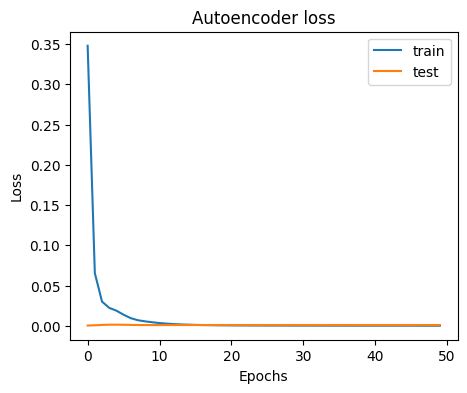

In [40]:
fig, ax = plt.subplots(figsize=(5,4)) 
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.title('Autoencoder loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Autoencoderloss.png')
     

4/4 [==============================] - 0s 20ms/step


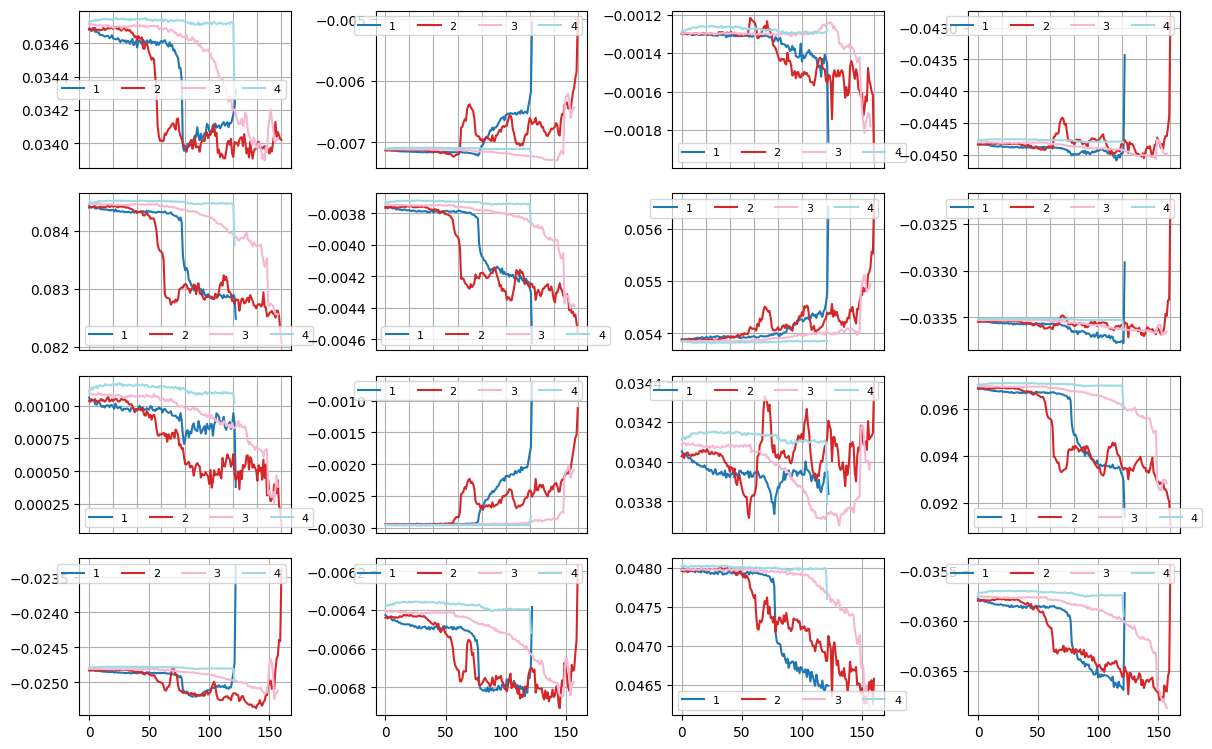

In [42]:
path = r'Dataset\XJTU\STFT\B2_2'
path = r'Dataset\XJTU\STFT\B1_1_env'
frames = []
folder = r'Dataset/XJTU\STFT/'
brngs = ['B1_1_env','B1_2_env','B1_3_env','B1_4_env']

for brng in brngs:
    path = os.path.join(folder, brng)
    data = load_bearing_data(path) # Ex: (123, 257, 129, 1)

    # 3. Junta os dois conjuntos no eixo 0 (amostras)
    X_val = np.concatenate([data], axis=0)
    X_val = (X_val - min_val) / (max_val - min_val)

    Z = encoder.predict(X_val)
    c1,c2,c3 = Z.shape
    Z = np.reshape(Z, (c2, c1, c3))
    #Z = np.reshape(Z, (1, 123, 32))

    df3 = pd.DataFrame(Z[0])
    frames.append(df3)
PlotDataframes(frames)

